<a href="https://colab.research.google.com/github/Zetastico/Inteligencia-Artificial-I/blob/main/Laboratorio_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 03

## Regresión Logística

In [40]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Preparación de los datos

In [42]:

# Primero buscamos la direccion del dataset
# Para abrir con drive
path = '/content/drive/MyDrive/IA Dataset/Dataset_Regresion_Log_50k.csv'

# Para abrir sin drive
# path = 'Dataset_Regresion_Log_50k.csv'

# Cargamos el dataset usando pandas
# Y luego lo leemos
df = pd.read_csv(path)

# Tomamos los primeros 20,000 datos
df_red = df.head(20000).copy()

# Seleccionamos las 20 propiedades (X) y la etiqueta (y)
X_raw = df_red.iloc[:, :20].values

# Convertimos etiquetas de texto a binario (1 si es ataque, 0 si es normal)
# En este dataset casi todo es ataque, así que marcamos 'DDoS' como 1
y = df_red['label'].apply(lambda x: 1 if 'DDoS' in str(x) else 0).values



# Datos de prueba (Los 4000 restantes)
X_test_raw = df.iloc[20000:24000, :20].values
y_test = df.iloc[20000:24000]['label'].apply(lambda x: 1 if 'DDoS' in str(x) else 0).values


## Normalizar los datos
### Tanto de los datos de entrenamiento como los de prueba

In [43]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X_raw)
X_tnorm, mut, sigmat = featureNormalize(X_test_raw)

##Función sigmoidea

In [44]:
def sigmoid(z):

    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

## Prueba del funcionamiento de la Función Sigmoidea

In [45]:
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


## Funcion de costo

### Configuramos la matriz y aumentamos la columna de 1s a X

In [46]:
m, n = X_norm.shape

X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Dataset listo: {m} ejemplos y {n} características + intercepto.")


m_test = X_tnorm.shape[0]

X_test = np.concatenate([np.ones((m_test, 1)), X_tnorm], axis=1)

Dataset listo: 20000 ejemplos y 20 características + intercepto.


### Funcion De Costo

In [47]:
def calcularCosto(X, y, theta):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-5)) - (1 - y).dot(np.log(1 - h + 1e-5)))
    return J

## Descenso por la Gradiente

In [48]:
def descensoGradiente(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

## Entrenamiento

Text(0.5, 1.0, 'Aprendizaje en Dataset de Red')

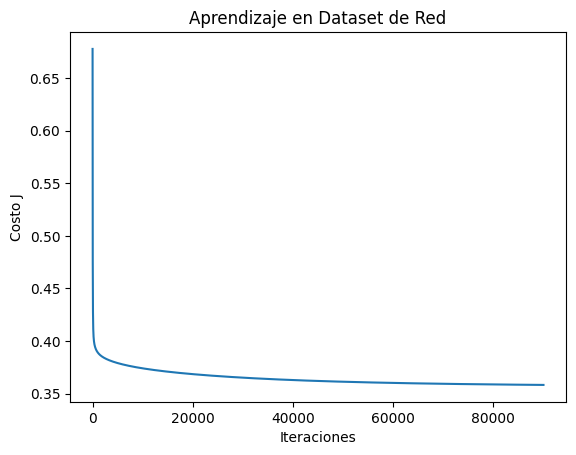

In [49]:
# Inicializar
# 20 variables + 1 sesgo
theta_inicial = np.zeros(21)
alpha = 0.1
num_iters = 90000

theta_final, J_history = descensoGradiente(X, y, theta_inicial, alpha, num_iters)

# Graficar Convergencia
pyplot.plot(J_history)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Aprendizaje en Dataset de Red')

## Precisión en el dataset

In [50]:
def predict(theta, X):
    return np.round(sigmoid(X.dot(theta.T)))

p = predict(theta_final, X)
print('Precisión en el dataset de red: {:.2f} %'.format(np.mean(p == y) * 100))

Precisión en el dataset de red: 83.31 %


## Pruebas (4000 datos)

In [51]:
# Realizar predicciones sobre los datos de prueba
p_test = predict(theta_final, X_test)

# Calcular precisión
accuracy_test = np.mean(p_test == y_test) * 100

print(f"Precisión en Entrenamiento (20k datos): {np.mean(predict(theta_final, X)) * 100:.2f}%")
print(f"Precisión en Prueba (4k datos nuevos): {accuracy_test:.2f}%")

Precisión en Entrenamiento (20k datos): 87.33%
Precisión en Prueba (4k datos nuevos): 77.58%
